In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [3]:
holding_period = 5
tickers = sp100["ticker"].values
factors = ["rolling_" + str(i) for i in [5,10,20,60,100]]
positions = len(sp100["GICS Sector"].unique())
training_year = 2020
training_years = 4

In [4]:
market.connect()
model = XGBRegressor(booster="gbtree",objective ='reg:absoluteerror', colsample_bytree = 0.3, learning_rate = 0.1,
                        max_depth = 5, alpha = 10, n_estimators = 100,verbosity=0,refit=False)
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        for days in [5,10,20,60,100]:
            ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        model_data = ticker_prices[(ticker_prices["year"]<=training_year) & (ticker_prices["year"]>=training_year-training_years)].dropna().reset_index(drop=True)
        model.fit(model_data[factors],model_data["y"])
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  18%|██████████████████████▎                                                                                                      | 18/101 [00:08<00:25,  3.23it/s]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:30<00:00,  3.31it/s]


In [5]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        for days in [5,10,20,60,100]:
            ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].dropna().reset_index(drop=True)
        simulation["prediction"] = model.predict(simulation[factors])
        simulation.sort_values("date",inplace=True)
        simulation["predicted_return"] = (simulation["prediction"] - simulation["adjclose"]) / simulation["adjclose"]
        simulation["signal"] = simulation["predicted_return"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["abs"] = simulation["signal"].abs()
        simulation["direction"] = simulation["signal"] / simulation["abs"] * -1
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions) * simulation["direction"]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  20%|████████████████████████▊                                                                                                    | 20/101 [00:03<00:11,  6.88it/s]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:20<00:00,  4.87it/s]


In [6]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp100,on="ticker")

In [14]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()

In [15]:
trades = processor.column_date_processing(trades[["date","abs","direction","ticker","GICS Sector","adjclose","return"]])

In [16]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [17]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

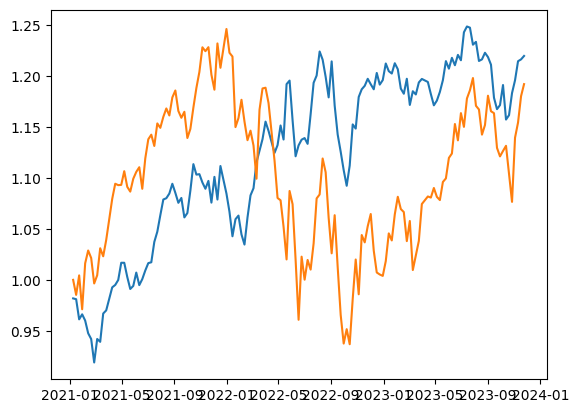

In [18]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [19]:
recommendations = trades.tail(positions)

In [20]:
recommendations

,date,abs,direction,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
1617,2023-12-01 00:00:00+00:00,1.013454,-1.0,T,Communication Services,16.760000,NaN,2023,4,12,48,4
1618,2023-12-01 00:00:00+00:00,2.189555,-1.0,F,Consumer Discretionary,10.580000,NaN,2023,4,12,48,4
1619,2023-12-01 00:00:00+00:00,0.895929,1.0,COST,Consumer Staples,596.250000,NaN,2023,4,12,48,4
1620,2023-12-01 00:00:00+00:00,0.571490,1.0,CVX,Energy,144.810000,NaN,2023,4,12,48,4
1621,2023-12-01 00:00:00+00:00,0.917406,1.0,BLK,Financials,751.294658,NaN,2023,4,12,48,4
1622,2023-12-01 00:00:00+00:00,0.893753,1.0,LLY,Health Care,584.040000,NaN,2023,4,12,48,4
1623,2023-12-01 00:00:00+00:00,0.861925,1.0,LMT,Industrials,449.410000,NaN,2023,4,12,48,4
1624,2023-12-01 00:00:00+00:00,0.933277,1.0,AVGO,Information Technology,930.000000,NaN,2023,4,12,48,4
1625,2023-12-01 00:00:00+00:00,0.849277,1.0,LIN,Materials,411.700000,NaN,2023,4,12,48,4
1626,2023-12-01 00:00:00+00:00,0.705172,1.0,AMT,Real Estate,210.470000,NaN,2023,4,12,48,4


In [21]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()